# 01 — Whole-slide exploration (interactive)
Inspect QC, FOV structure, expression clustering, and spatial/FOV association without committing parameters to production.

In [1]:
# ============================================================
# Dataset_02 CosMx — Jupyter initialization
# ============================================================

from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc


# ------------------------------------------------------------
# Robustly locate project root
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    """
    Search current directory and its parents for the project root.

    A valid project root contains:
        src/
        data/
    """

    for candidate in [start, *start.parents]:

        if (
            (candidate / "src").is_dir()
            and
            (candidate / "data").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate project root.\n"
        f"Starting directory: {start}\n\n"
        "Expected a parent directory containing:\n"
        "  src/\n"
        "  data/"
    )


PROJECT_ROOT = find_project_root(CURRENT_DIR)


# ------------------------------------------------------------
# Make src importable
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )


# ------------------------------------------------------------
# Common paths
# ------------------------------------------------------------

RAW_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

SPATIAL_DIR = (
    PROJECT_ROOT
    / "data"
    / "spatial"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

CONFIG_DIR = (
    PROJECT_ROOT
    / "config"
)


# ------------------------------------------------------------
# Scanpy settings
# ------------------------------------------------------------

sc.settings.verbosity = 2


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)

print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)

print()

print(
    "src exists         :",
    (PROJECT_ROOT / "src").exists(),
)

print(
    "raw data exists    :",
    RAW_DIR.exists(),
)

print(
    "processed exists   :",
    PROCESSED_DIR.exists(),
)

print(
    "spatial exists     :",
    SPATIAL_DIR.exists(),
)

Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python

src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [2]:
ADATA_PATH = (
    PROCESSED_DIR
    / "GSM9046088_CosMx_raw.h5ad"
)

print("ADATA_PATH:")
print(ADATA_PATH)

print()

print(
    "ADATA_PATH exists:",
    ADATA_PATH.exists(),
)

ADATA_PATH:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/data/processed/GSM9046088_CosMx_raw.h5ad

ADATA_PATH exists: True


In [3]:
import src

print(
    "src imported from:"
)

print(
    src.__file__
)

src imported from:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/src/__init__.py


In [4]:
from src.qc import add_qc_metrics
from src.cosmx_io import control_mask

print("Project imports OK")

Project imports OK


In [5]:
a = sc.read_h5ad(
    ADATA_PATH
)

print(a)

AnnData object with n_obs × n_vars = 43565 × 1010
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'GEO_accession', 'fov_positions', 'platform', 'sample', 'spatial_coordinate_columns'
    obsm: 'spatial'
    layers: 'counts'


In [7]:
add_qc_metrics(a)

qc_columns = [
    c
    for c in [
        "fov",
        "total_counts",
        "n_genes_by_counts",
        "control_fraction",
        "qc_cell_area",
    ]
    if c in a.obs.columns
]

print(
    "QC columns:",
    qc_columns,
)

display(
    a.obs[
        qc_columns
    ].head()
)

QC columns: ['fov', 'total_counts', 'n_genes_by_counts', 'control_fraction', 'qc_cell_area']


,fov,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
unique_cell_id,,,,,
fov_1_cell_1,1,106.0,39,0.00000,7538
fov_1_cell_2,1,96.0,76,0.00000,4969
fov_1_cell_3,1,156.0,87,0.00641,4045
fov_1_cell_4,1,308.0,192,0.00000,7853
fov_1_cell_5,1,18.0,17,0.00000,7992


In [8]:
display(
    a.obs[
        qc_columns
    ].describe()
)

,fov,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
count,43565.000000,43565.000000,43565.000000,43565.000000,43565.000000
mean,20.103661,308.306244,123.841800,0.001584,7042.187582
std,12.671030,332.771881,92.885545,0.011622,3283.435630
min,1.000000,0.000000,0.000000,0.000000,60.000000
25%,10.000000,80.000000,50.000000,0.000000,4708.000000
50%,19.000000,224.000000,114.000000,0.000000,6481.000000
75%,28.000000,425.000000,181.000000,0.000000,8719.000000
max,46.000000,4403.000000,622.000000,1.000000,37854.000000


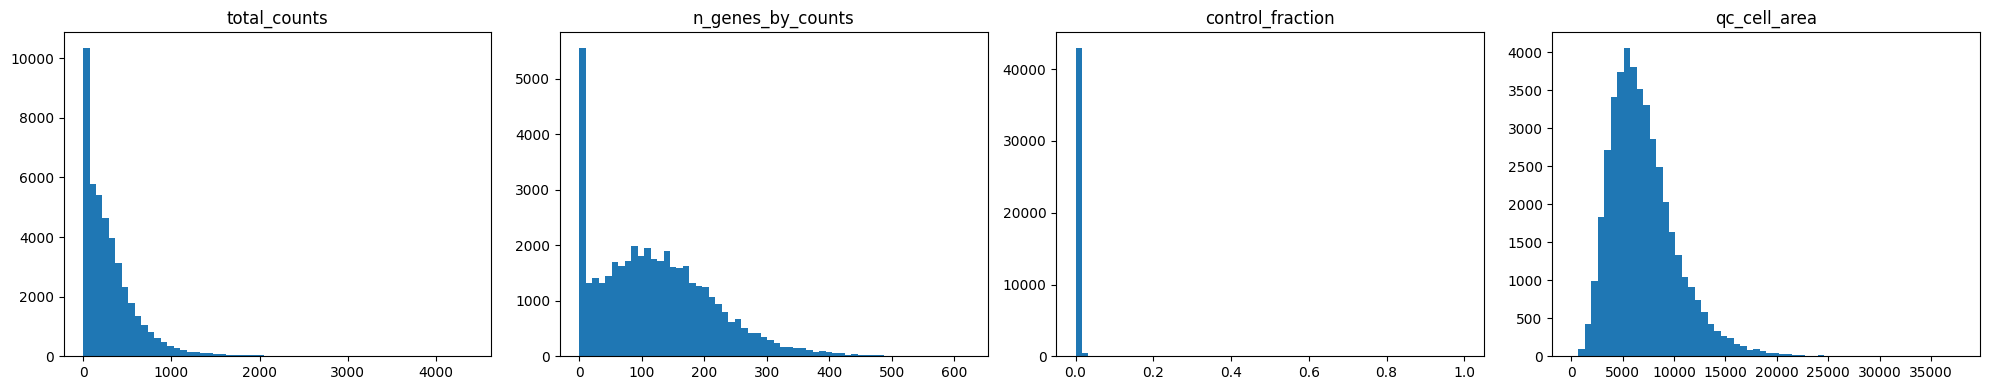

In [9]:
# Interactive QC visualization: change metrics/quantiles and rerun.
QC_METRICS = [c for c in ["total_counts","n_genes_by_counts","control_fraction","qc_cell_area"] if c in a.obs]
fig, axes = plt.subplots(1, len(QC_METRICS), figsize=(5*len(QC_METRICS),4))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, QC_METRICS):
    vals = pd.to_numeric(a.obs[col], errors="coerce").dropna()
    ax.hist(vals, bins=60)
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [10]:
# FOV-level QC summaries.
qc_by_fov = a.obs.groupby("fov", observed=True).agg(
    n_cells=("total_counts","size"),
    median_counts=("total_counts","median"),
    median_genes=("n_genes_by_counts","median"),
    median_control_fraction=("control_fraction","median"),
)
display(qc_by_fov.sort_values("n_cells", ascending=False).head(20))

,n_cells,median_counts,median_genes,median_control_fraction
fov,,,,
8,1945,235.0,137.0,0.0
28,1852,194.0,105.0,0.0
7,1762,269.0,146.0,0.0
13,1756,337.0,156.0,0.0
27,1580,171.0,98.0,0.0
26,1497,335.0,148.0,0.0
9,1403,280.0,145.0,0.0
29,1386,421.5,195.0,0.0
17,1369,14.0,12.0,0.0


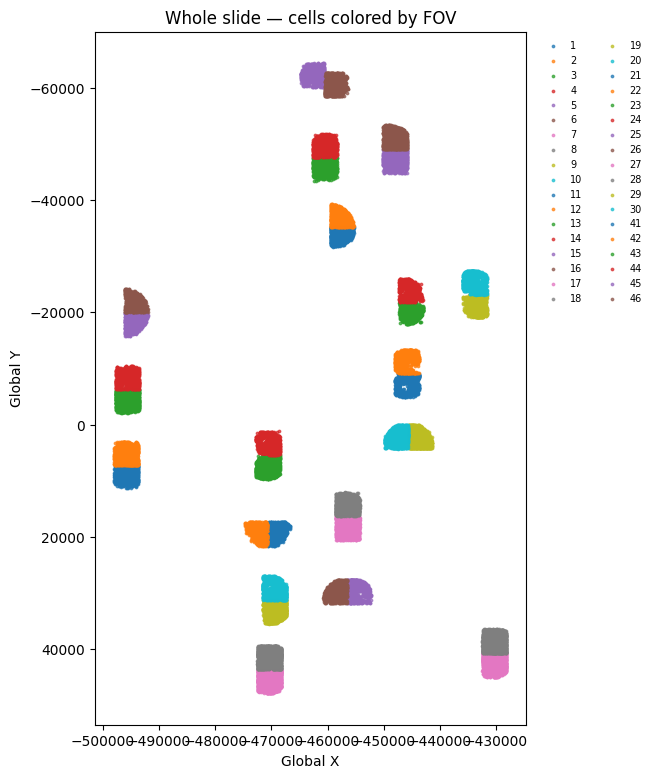

In [11]:
# Spatial layout colored by FOV.
xy = np.asarray(a.obsm["spatial"])
fig, ax = plt.subplots(figsize=(9,9))
for fov, idx in a.obs.groupby("fov", observed=True).groups.items():
    pos = a.obs_names.get_indexer(idx)
    ax.scatter(xy[pos,0], xy[pos,1], s=3, label=str(fov), alpha=.7)
ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xlabel("Global X"); ax.set_ylabel("Global Y")
ax.set_title("Whole slide — cells colored by FOV")
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left", ncol=2, fontsize=7, frameon=False)
plt.show()

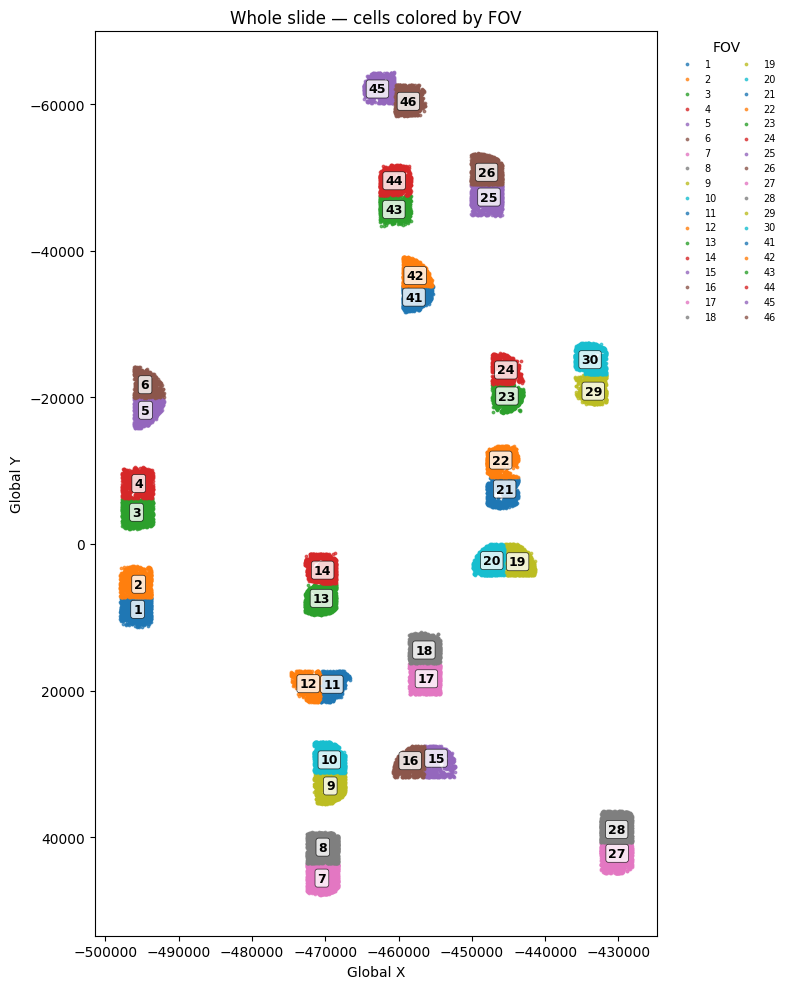

In [12]:
# Spatial layout colored by FOV + FOV labels.

xy = np.asarray(a.obsm["spatial"])

fig, ax = plt.subplots(figsize=(10, 10))

for fov, idx in a.obs.groupby("fov", observed=True).groups.items():

    # Convert cell names to integer positions
    pos = a.obs_names.get_indexer(idx)

    x = xy[pos, 0]
    y = xy[pos, 1]

    # Plot cells
    ax.scatter(
        x,
        y,
        s=3,
        label=str(fov),
        alpha=0.7,
    )

    # --------------------------------------------------------
    # Add FOV label at the center of each spatial group
    # Median is more robust than mean for irregular shapes.
    # --------------------------------------------------------

    label_x = np.median(x)
    label_y = np.median(y)

    ax.text(
        label_x,
        label_y,
        str(fov),
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="black",
            alpha=0.8,
            linewidth=0.5,
        ),
        zorder=10,
    )


# ------------------------------------------------------------
# Theme
# ------------------------------------------------------------

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xlabel("Global X")
ax.set_ylabel("Global Y")

ax.set_title(
    "Whole slide — cells colored by FOV"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    ncol=2,
    fontsize=7,
    frameon=False,
    title="FOV",
)

plt.tight_layout()
plt.show()

## Optional whole-slide expression clustering
Adjust `MIN_COUNTS`, `MIN_GENES`, `N_PCS`, `N_NEIGHBORS`, and `RESOLUTION`, then rerun only this section.

normalizing counts per cell
    finished (0:00:00)


/home/jqu/.conda/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=30
    finished (0:00:03)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:40)
computing UMAP
    finished (0:00:29)
running Leiden clustering


/lsf_tmp/323066199.tmpdir/ipykernel_1578405/4142125367.py:16: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(b, resolution=RESOLUTION, key_added="leiden", random_state=SEED)


    finished (0:00:26)


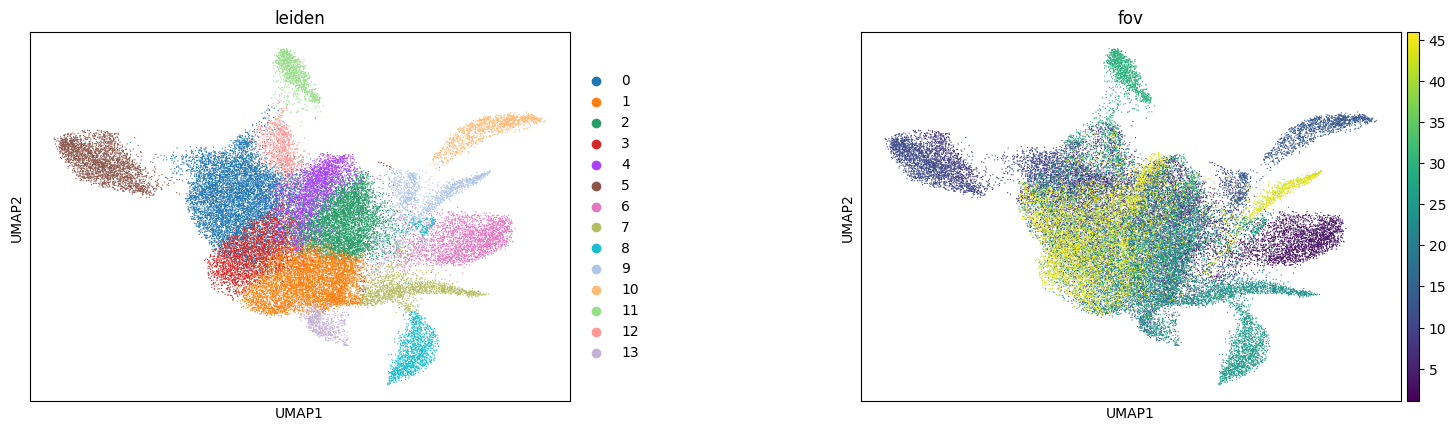

In [13]:
MIN_COUNTS = 20
MIN_GENES = 10
N_PCS = 30
N_NEIGHBORS = 15
RESOLUTION = 0.5
SEED = 42

b = a[(a.obs.total_counts >= MIN_COUNTS) & (a.obs.n_genes_by_counts >= MIN_GENES), ~a.var["is_control"].to_numpy()].copy()
sc.pp.filter_genes(b, min_cells=1)
b.layers["counts"] = b.X.copy()
sc.pp.normalize_total(b, target_sum=1e4); sc.pp.log1p(b); b.raw = b.copy(); sc.pp.scale(b, max_value=10)
npcs = min(N_PCS, b.n_obs-1, b.n_vars-1)
sc.tl.pca(b, n_comps=npcs, svd_solver="arpack", random_state=SEED)
sc.pp.neighbors(b, n_neighbors=N_NEIGHBORS, n_pcs=npcs, random_state=SEED)
sc.tl.umap(b, random_state=SEED)
sc.tl.leiden(b, resolution=RESOLUTION, key_added="leiden", random_state=SEED)
sc.pl.umap(b, color=["leiden","fov"], frameon=True, wspace=.4)

fov,1,2,3,4,5,6,7,8,9,10,...,27,28,29,30,41,42,43,44,45,46
leiden,,,,,,,,,,,,,,,,,,,,,
0,0.013866,0.019472,0.019029,0.007376,0.039534,0.032158,0.085558,0.091901,0.067267,0.061366,...,0.020062,0.043074,0.026995,0.037321,0.015489,0.034076,0.041894,0.045434,0.050745,0.016669
1,0.012239,0.014788,0.012409,0.007819,0.006119,0.005949,0.035356,0.039606,0.023457,0.016658,...,0.058134,0.080911,0.011729,0.009349,0.025327,0.017168,0.033996,0.044875,0.020228,0.035356
2,0.031880,0.030536,0.044555,0.034953,0.009218,0.011331,0.104283,0.116958,0.032648,0.015172,...,0.079892,0.102362,0.082389,0.020549,0.005954,0.014404,0.013828,0.022278,0.013828,0.009410
3,0.005258,0.022082,0.003856,0.004907,0.030494,0.024886,0.027340,0.025938,0.011917,0.015072,...,0.052576,0.053277,0.003155,0.002103,0.158430,0.142657,0.043113,0.035401,0.059586,0.121977
4,0.028571,0.036429,0.031786,0.030714,0.045357,0.044286,0.027857,0.032143,0.005714,0.008929,...,0.052500,0.028214,0.030714,0.026429,0.045000,0.053214,0.047143,0.048571,0.074643,0.071071
5,0.000364,0.000364,0.000000,0.000000,0.000729,0.000000,0.069242,0.071429,0.188047,0.237245,...,0.000364,0.000364,0.000364,0.000364,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.240239,0.223904,0.254183,0.206773,0.008765,0.046614,0.000000,0.000000,0.000000,0.000000,...,0.002390,0.004382,0.000398,0.002390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.014963,0.017456,0.008728,0.007481,0.000623,0.002494,0.000000,0.006858,0.001870,0.001870,...,0.016209,0.032419,0.003741,0.007481,0.000000,0.001247,0.000623,0.000623,0.001870,0.000623
8,0.000000,0.000000,0.000641,0.000000,0.001281,0.001281,0.000000,0.000641,0.000000,0.000000,...,0.042921,0.081999,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


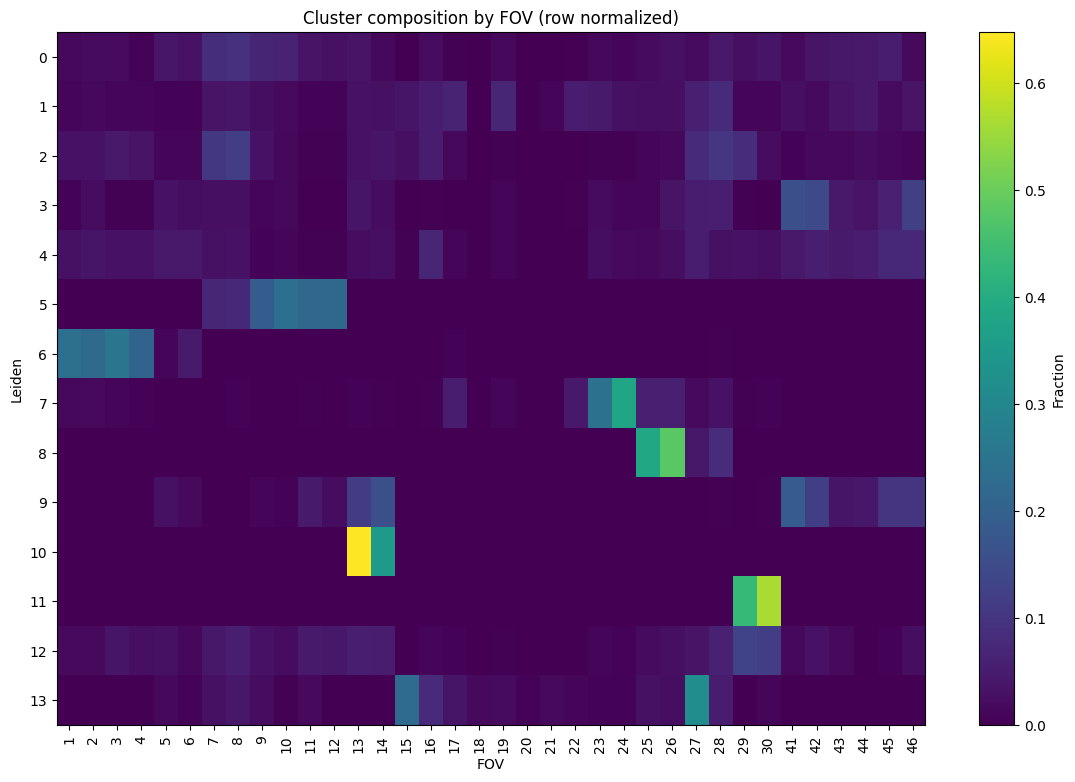

In [14]:
# Quantify cluster × FOV association.
cluster_fov = pd.crosstab(b.obs["leiden"], b.obs["fov"], normalize="index")
display(cluster_fov)
fig, ax = plt.subplots(figsize=(14, max(4, .5*cluster_fov.shape[0]+2)))
im=ax.imshow(cluster_fov, aspect="auto")
ax.set_yticks(range(cluster_fov.shape[0]), cluster_fov.index.astype(str))
ax.set_xticks(range(cluster_fov.shape[1]), cluster_fov.columns.astype(str), rotation=90)
ax.set_xlabel("FOV"); ax.set_ylabel("Leiden"); ax.set_title("Cluster composition by FOV (row normalized)")
fig.colorbar(im, ax=ax, label="Fraction"); plt.show()